## California Housing Price Prediction

### Dataset Loading

In [117]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [118]:
data = fetch_california_housing(as_frame=True)  # returns as pandas dataframe object
df = data.frame

In [119]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Splitting Data

In [120]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

### Train/Test Split

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

### Feature Scaling

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Converting to Tensors

In [123]:
import torch

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

### Wrapping into Dataset and DataLoader

In [124]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

### Neural Network

In [125]:
import torch.nn as nn

In [126]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


### Loss Function and Optimizer

In [127]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training & Testing

In [128]:
train_losses = []
test_losses = []

epochs = 20

for epoch in range(epochs):
    
    #Training
    model.train()
    epoch_train_loss = 0
    
    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        epoch_train_loss += loss.item()
        
    epoch_train_loss /= len(train_loader)   # calculate avg loss per batch
    train_losses.append(epoch_train_loss)
    
    #Testing
    model.eval()
    epoch_val_loss = 0
    
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            loss = loss_fn(preds, yb)
            epoch_val_loss += loss.item()
            
        epoch_val_loss /= len(test_loader)
        test_losses.append(epoch_val_loss)
        
    print(
        f"Epoch: {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Test Loss: {epoch_val_loss:.4f}"
    )

Epoch: 00 | Train Loss: 1.6366 | Test Loss: 0.6169
Epoch: 01 | Train Loss: 0.5199 | Test Loss: 0.4623
Epoch: 02 | Train Loss: 0.4349 | Test Loss: 0.4293
Epoch: 03 | Train Loss: 0.4044 | Test Loss: 0.4057
Epoch: 04 | Train Loss: 0.3849 | Test Loss: 0.3882
Epoch: 05 | Train Loss: 0.3717 | Test Loss: 0.3770
Epoch: 06 | Train Loss: 0.3633 | Test Loss: 0.3677
Epoch: 07 | Train Loss: 0.3600 | Test Loss: 0.3553
Epoch: 08 | Train Loss: 0.3473 | Test Loss: 0.3624
Epoch: 09 | Train Loss: 0.3378 | Test Loss: 0.3494
Epoch: 10 | Train Loss: 0.3304 | Test Loss: 0.3518
Epoch: 11 | Train Loss: 0.3291 | Test Loss: 0.3527
Epoch: 12 | Train Loss: 0.3199 | Test Loss: 0.3280
Epoch: 13 | Train Loss: 0.3223 | Test Loss: 0.3261
Epoch: 14 | Train Loss: 0.3171 | Test Loss: 0.3262
Epoch: 15 | Train Loss: 0.3097 | Test Loss: 0.3180
Epoch: 16 | Train Loss: 0.3122 | Test Loss: 0.3236
Epoch: 17 | Train Loss: 0.3060 | Test Loss: 0.3091
Epoch: 18 | Train Loss: 0.3016 | Test Loss: 0.3104
Epoch: 19 | Train Loss: 0.3021 

Training block

- model.train() → training mode
- gradients ON
- weights update

Validation block

- model.eval() → evaluation mode
- gradients OFF
- no learning happens

### Visualization

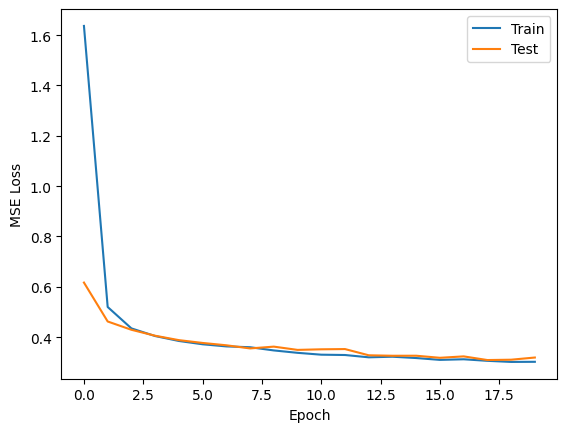

In [129]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

### Saving the model

In [130]:
torch.save(model.state_dict(), "housing_model.pth")

### Loading the model back

In [131]:
model_loaded = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

In [132]:
model_loaded.load_state_dict(torch.load("housing_model.pth"))
model_loaded.eval()

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

### Making Predictions with loaded model

In [ ]:
with torch.no_grad():
    sample_preds = model_loaded(X_test[:5])
    loss = loss_fn(sample_preds, y_test[:5])
    
print(loss.item())

0.22894509136676788
